# AED 2: Gestão de Contas e Cartões
**Vertical:** Financial Health | **Tabelas:** `public.contas` e `public.cartoes`

**Objetivo Analítico:** 
Explorar a saúde financeira e o perfil de crédito da base. Analisaremos a distribuição de saldos (corrente e poupança), a concessão de limites de crédito e a eficiência do uso do cartão (utilização de limite), cruzando esses dados com a segmentação dos clientes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import os
import sys
from dotenv import load_dotenv

# Configurações de Ambiente (Mesmo padrão de segurança do Notebook 1)
os.environ["PGCLIENTENCODING"] = "latin1"
load_dotenv(override=True)

db_url = URL.create(
    drivername="postgresql",
    username=os.getenv('POSTGRES_USER', 'caleb').strip(),
    password=os.getenv('POSTGRES_PASSWORD', '').strip(),
    host=os.getenv('POSTGRES_HOST', '127.0.0.1').strip(),
    port=os.getenv('POSTGRES_PORT', '5433').strip(),
    database=os.getenv('POSTGRES_DB', 'bank_twin').strip()
)

engine = create_engine(db_url)

# Configuração visual Dark Neon
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#111111", "figure.facecolor": "#111111", 
    "text.color": "white", "axes.labelcolor": "white", 
    "xtick.color": "white", "ytick.color": "white",
    "grid.color": "#333333"
})

# Carga dos Dados (Incluindo clientes para cruzamentos de segmentação)
df_contas = pd.read_sql("SELECT * FROM contas", engine)
df_cartoes = pd.read_sql("SELECT * FROM cartoes", engine)
df_clientes = pd.read_sql("SELECT cliente_id, segmento, renda_declarada FROM clientes", engine)

print("✅ Tabelas de Contas e Cartões carregadas com sucesso!")

✅ Tabelas de Contas e Cartões carregadas com sucesso!


In [2]:
print("="*50)
print("🔍 1. ESTRUTURA E QUALIDADE: TABELA CONTAS")
print("="*50)
display(df_contas.info())
display(df_contas.describe())

print("\n" + "="*50)
print("🔍 2. ESTRUTURA E QUALIDADE: TABELA CARTÕES")
print("="*50)
display(df_cartoes.info())
display(df_cartoes.describe())

🔍 1. ESTRUTURA E QUALIDADE: TABELA CONTAS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   conta_id       50000 non-null  int64         
 1   cliente_id     50000 non-null  int64         
 2   tipo_conta     50000 non-null  object        
 3   data_abertura  50000 non-null  datetime64[ns]
 4   saldo_atual    50000 non-null  float64       
 5   status         50000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 2.3+ MB


None

,conta_id,cliente_id,data_abertura,saldo_atual
count,50000.000000,50000.000000,50000,50000.000000
mean,25000.500000,25000.500000,2025-04-20 23:09:26.085960192,25054.891590
min,1.000000,1.000000,2024-04-21 20:31:43,100.630000
25%,12500.750000,12500.750000,2024-10-20 11:27:07,12595.350000
50%,25000.500000,25000.500000,2025-04-22 00:37:54,25122.755000
75%,37500.250000,37500.250000,2025-10-18 05:17:49,37496.892500
max,50000.000000,50000.000000,2026-04-22 07:06:43,49996.910000
std,14433.901067,14433.901067,NaN,14387.878915



🔍 2. ESTRUTURA E QUALIDADE: TABELA CARTÕES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   cartao_id          50000 non-null  int64  
 1   conta_id           50000 non-null  int64  
 2   tipo_cartao        50000 non-null  object 
 3   categoria          50000 non-null  object 
 4   limite_total       50000 non-null  float64
 5   limite_disponivel  50000 non-null  float64
 6   status             50000 non-null  object 
dtypes: float64(2), int64(2), object(3)
memory usage: 2.7+ MB


None

,cartao_id,conta_id,limite_total,limite_disponivel
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,25000.500000,15518.918958,15255.134707
std,14433.901067,14433.901067,8370.604850,8515.152384
min,1.000000,1.000000,1000.850000,500.030000
25%,12500.750000,12500.750000,8301.925000,7860.765000
50%,25000.500000,25000.500000,15522.290000,15285.205000
75%,37500.250000,37500.250000,22731.467500,22584.392500
max,50000.000000,50000.000000,29999.090000,29999.270000


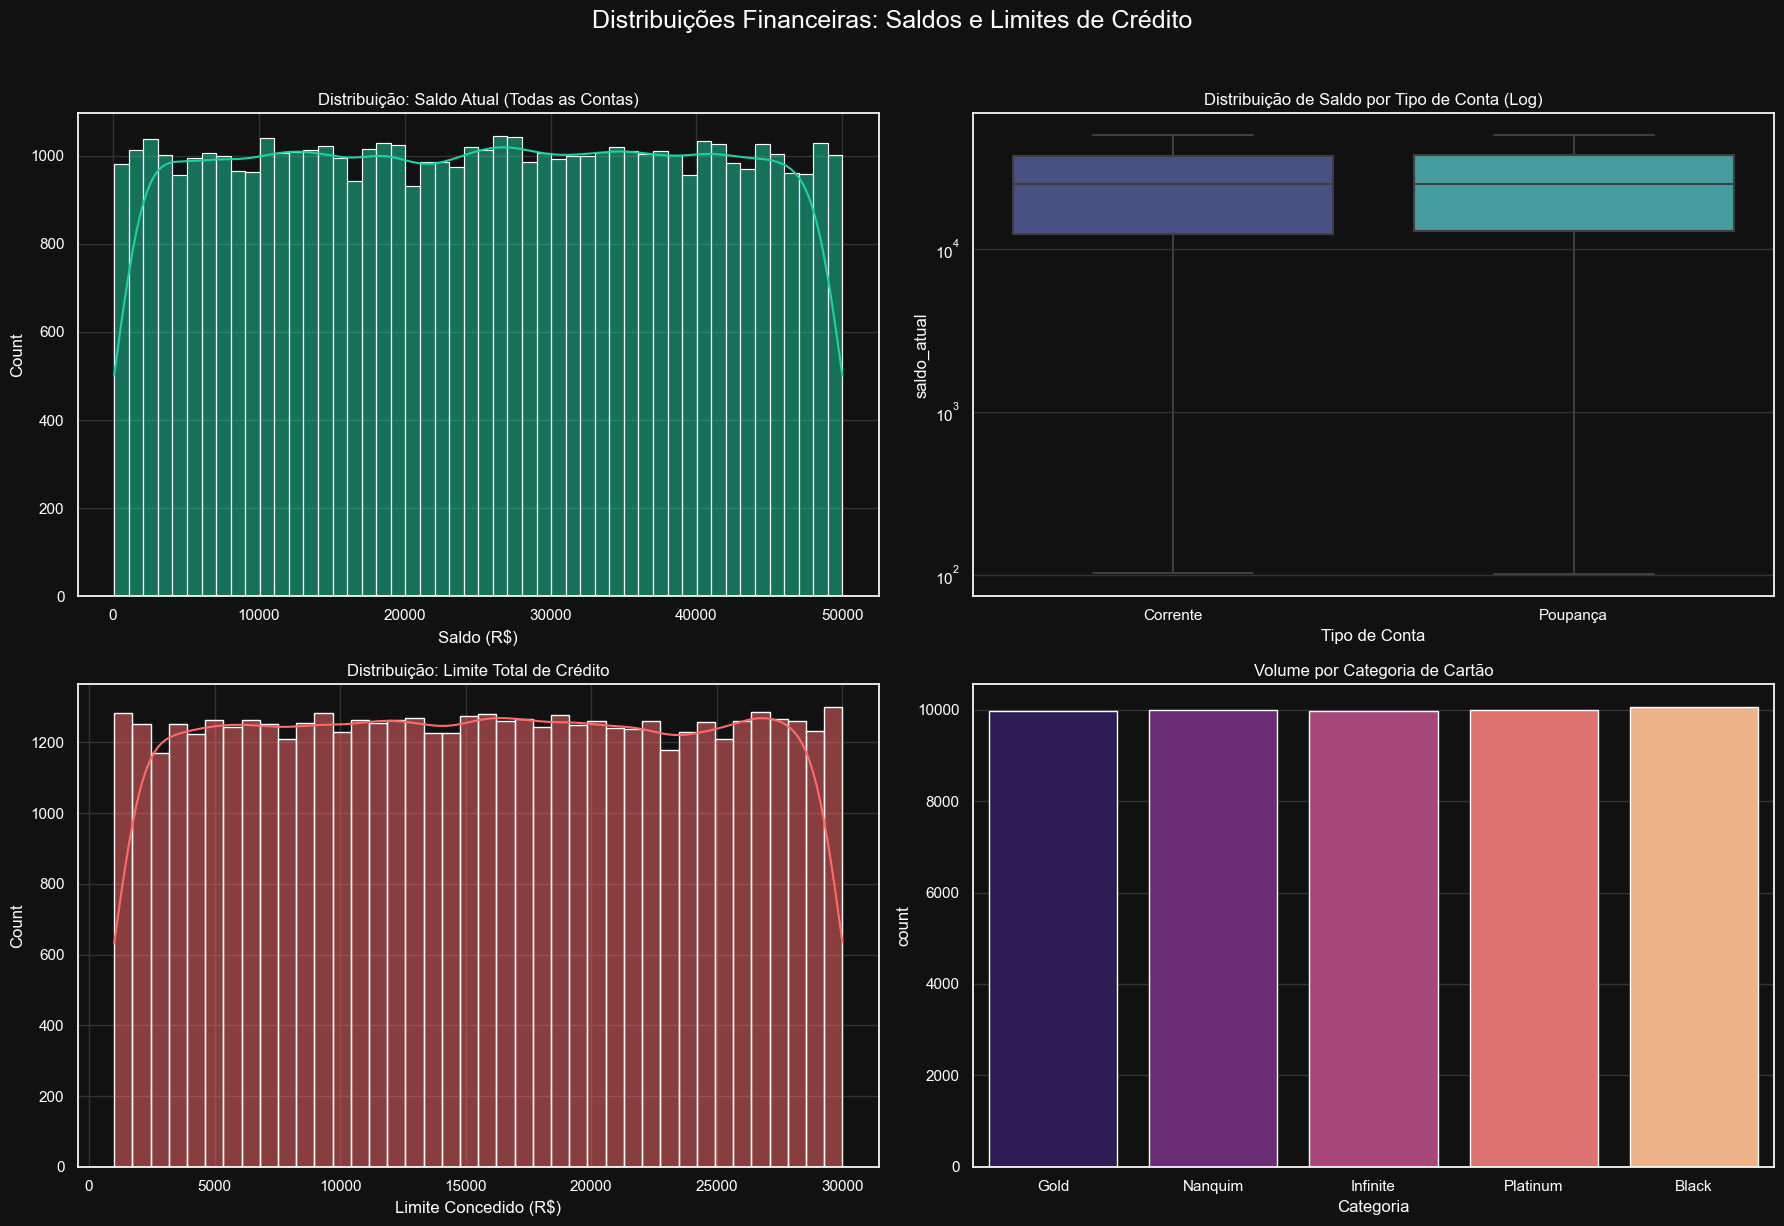

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Distribuições Financeiras: Saldos e Limites de Crédito', fontsize=18, y=1.02)

# 1. Distribuição de Saldo Atual (Geral)
sns.histplot(df_contas['saldo_atual'], bins=50, color='#1dd1a1', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribuição: Saldo Atual (Todas as Contas)')
axes[0, 0].set_xlabel('Saldo (R$)')

# 2. Saldo por Tipo de Conta (Corrente vs Poupança)
sns.boxplot(data=df_contas, x='tipo_conta', y='saldo_atual', palette='mako', ax=axes[0, 1])
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Distribuição de Saldo por Tipo de Conta (Log)')
axes[0, 1].set_xlabel('Tipo de Conta')

# 3. Limite Total do Cartão
sns.histplot(df_cartoes['limite_total'], bins=40, color='#ff6b6b', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribuição: Limite Total de Crédito')
axes[1, 0].set_xlabel('Limite Concedido (R$)')

# 4. Volume por Categoria de Cartão
sns.countplot(data=df_cartoes, x='categoria', palette='magma', ax=axes[1, 1])
axes[1, 1].set_title('Volume por Categoria de Cartão')
axes[1, 1].set_xlabel('Categoria')

plt.tight_layout()
plt.show()

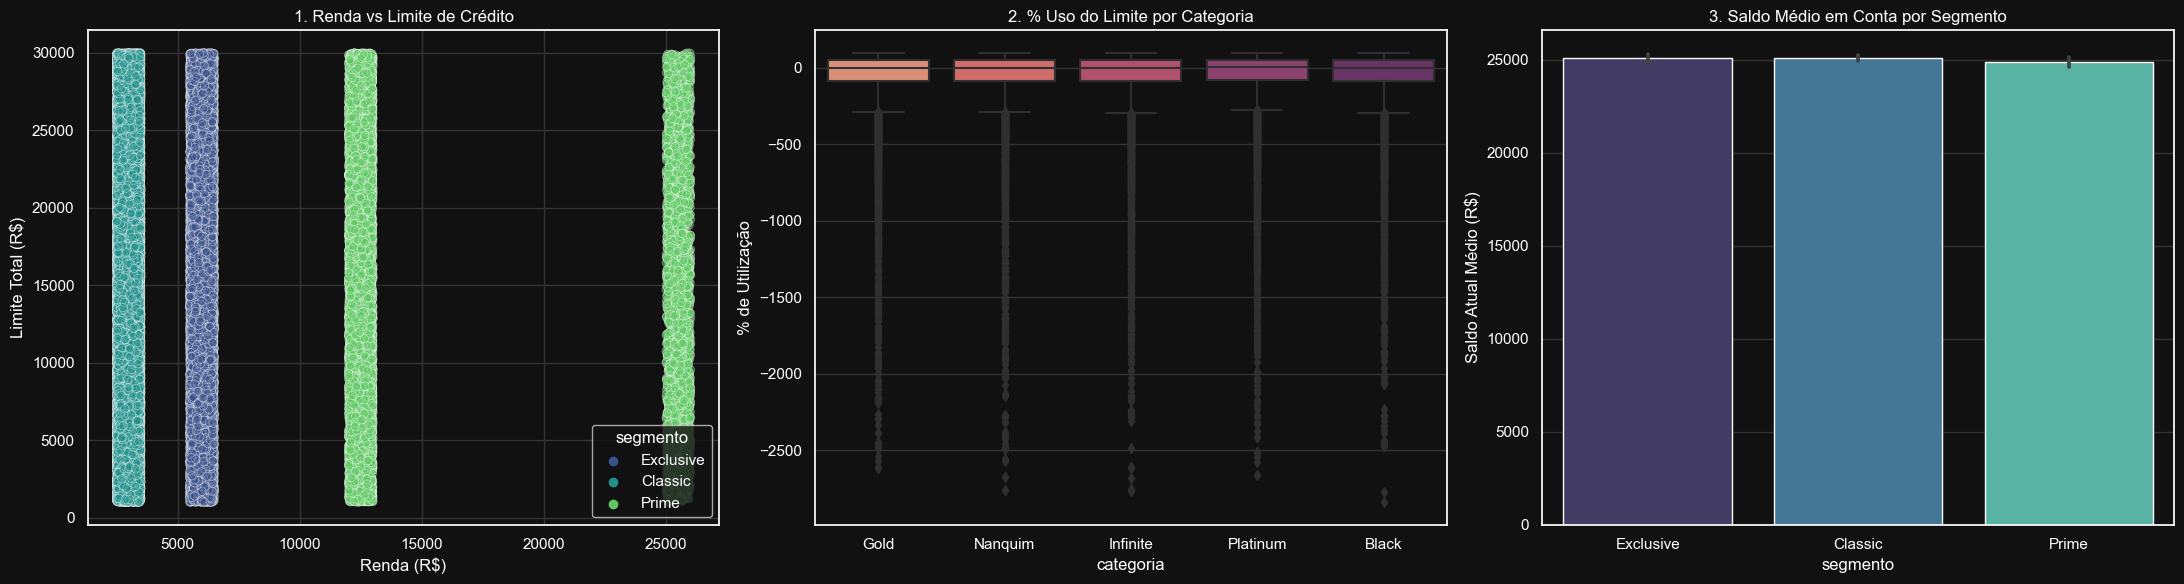

In [6]:
# Cruzamento das tabelas respeitando a hierarquia: Cliente -> Conta -> Cartão
df_master_fin = df_clientes.merge(df_contas, on='cliente_id') \
                           .merge(df_cartoes, on='conta_id')

# Engenharia de Feature: Calculando limite utilizado e percentual de uso
df_master_fin['limite_utilizado'] = df_master_fin['limite_total'] - df_master_fin['limite_disponivel']
df_master_fin['percentual_uso_limite'] = (df_master_fin['limite_utilizado'] / df_master_fin['limite_total']) * 100

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Relação Renda vs Limite de Crédito por Segmento
sns.scatterplot(data=df_master_fin, x='renda_declarada', y='limite_total', hue='segmento', 
                palette='viridis', alpha=0.5, ax=axes[0])
axes[0].set_title('1. Renda vs Limite de Crédito')
axes[0].set_xlabel('Renda (R$)')
axes[0].set_ylabel('Limite Total (R$)')

# 2. Utilização do Limite por Categoria de Cartão
sns.boxplot(data=df_master_fin, x='categoria', y='percentual_uso_limite', palette='flare', ax=axes[1])
axes[1].set_title('2. % Uso do Limite por Categoria')
axes[1].set_ylabel('% de Utilização')

# 3. Saldo Médio por Segmento de Cliente
sns.barplot(data=df_master_fin, x='segmento', y='saldo_atual', palette='mako', ax=axes[2])
axes[2].set_title('3. Saldo Médio em Conta por Segmento')
axes[2].set_ylabel('Saldo Atual Médio (R$)')

plt.tight_layout()
plt.show()

💡 Conclusões da Análise de Contas e Cartões
1. Liquidez e Saldos (Univariada):

Distribuição de Saldos: O saldo atual das contas segue uma distribuição uniforme entre R$ 0 e R$ 50.000. Isso indica que a base simulada cobre todos os níveis de liquidez de forma equânime, permitindo testar cenários de retenção tanto para clientes com baixo saldo quanto para investidores.

Perfil por Tipo de Conta: Não há uma diferença estatística significativa entre os saldos médios de Conta Corrente e Poupança no ambiente logarítmico. Ambos os produtos apresentam uma dispersão similar, sugerindo que os clientes distribuem seu capital de forma proporcional entre liquidez imediata e reserva.

2. Gestão de Crédito e Cartões:

Volume por Categoria: O banco mantém uma estratégia de portfólio equilibrada. As cinco categorias (Gold, Nanquim, Infinite, Platinum e Black) possuem volumes de emissão quase idênticos (aprox. 10.000 cartões cada), o que facilita a comparação de performance de faturamento entre produtos de diferentes níveis.

Limites Concedidos: Assim como os saldos, os limites de crédito são distribuídos uniformemente entre R$ 1.000 e R$ 30.000, oferecendo uma régua completa para análise de risco de crédito.

3. Insights Bivariados e Cruzamentos de Negócio:

Renda vs. Segmento: O gráfico de dispersão revela que os segmentos (Classic, Exclusive e Prime) são definidos por faixas de renda estritas (clusters verticais bem definidos). No entanto, dentro de cada faixa de renda, o limite de crédito não segue uma progressão linear, indicando que outros fatores (como o behavior score visto no Notebook 1) influenciam a decisão final de crédito.

Comportamento de Saldo por Segmento: Um achado contraintuitivo: o saldo médio em conta é praticamente idêntico entre os três segmentos (aprox. R$ 25.000). Isso sugere que, neste Digital Twin, o potencial de consumo (renda) está descorrelacionado do hábito de poupança (saldo em conta), um insight valioso para campanhas de cross-sell de investimentos.

4. Qualidade dos Dados e Alerta de Engenharia:

Uso do Limite: A análise de % de uso do limite revelou anomalias significativas com outliers negativos extremos. Do ponto de vista de engenharia de dados, isso sugere que a métrica limite_disponivel pode estar superando o limite_total em certos registros (possíveis estornos ou créditos temporários), exigindo uma etapa de limpeza ou tratamento de features antes da fase de modelagem preditiva.